# 1. 후기 궤적 시각화와 경험적 관리구간

## 목적과 가정

RC·OC·APC 정상 배치의 페니실린, 기질, OUR, pH 궤적을 실제 종료시간 비율이 아닌 고정 경과시간으로 비교한다. 선은 배치 중앙값, 음영은 25~75% 범위다. 확정 골든배치 15개로 계산하는 관리밴드는 현장 규격이나 공정 허용한계가 아니라 경험적 참고구간이다. CSV와 그림 파일은 저장하지 않는다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats


def find_project_root(start=Path.cwd()):
    for root in (start, *start.parents):
        if (root / 'data/interim/merged_data_ko.csv').exists():
            return root
    raise FileNotFoundError('merged_data_ko.csv를 찾을 수 없습니다.')


def fdr_bh(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0, 1)
    return result


golden_ids = [8, 12, 17, 26, 14, 16, 35, 57, 48, 79, 85, 65, 62, 82, 68]
data = pd.read_csv(find_project_root() / 'data/interim/merged_data_ko.csv')
data = data.loc[data['배치번호'] <= 90].copy()
data['전략'] = np.select([data['배치번호'] <= 30, data['배치번호'] <= 60], ['RC', 'OC'], default='APC')
print(f'정상 배치 {data["배치번호"].nunique()}개, 최소 종료시간 {data.groupby("배치번호")["발효시간(h)"].max().min():.1f}시간')

정상 배치 90개, 최소 종료시간 167.0시간


### 판단

정상 배치의 최소 종료시간은 167시간이다. 따라서 165시간까지는 90개 배치를 동일하게 비교할 수 있고, 그 이후 궤적은 종료되지 않은 배치만 남으므로 표본수 감소를 함께 확인해야 한다.

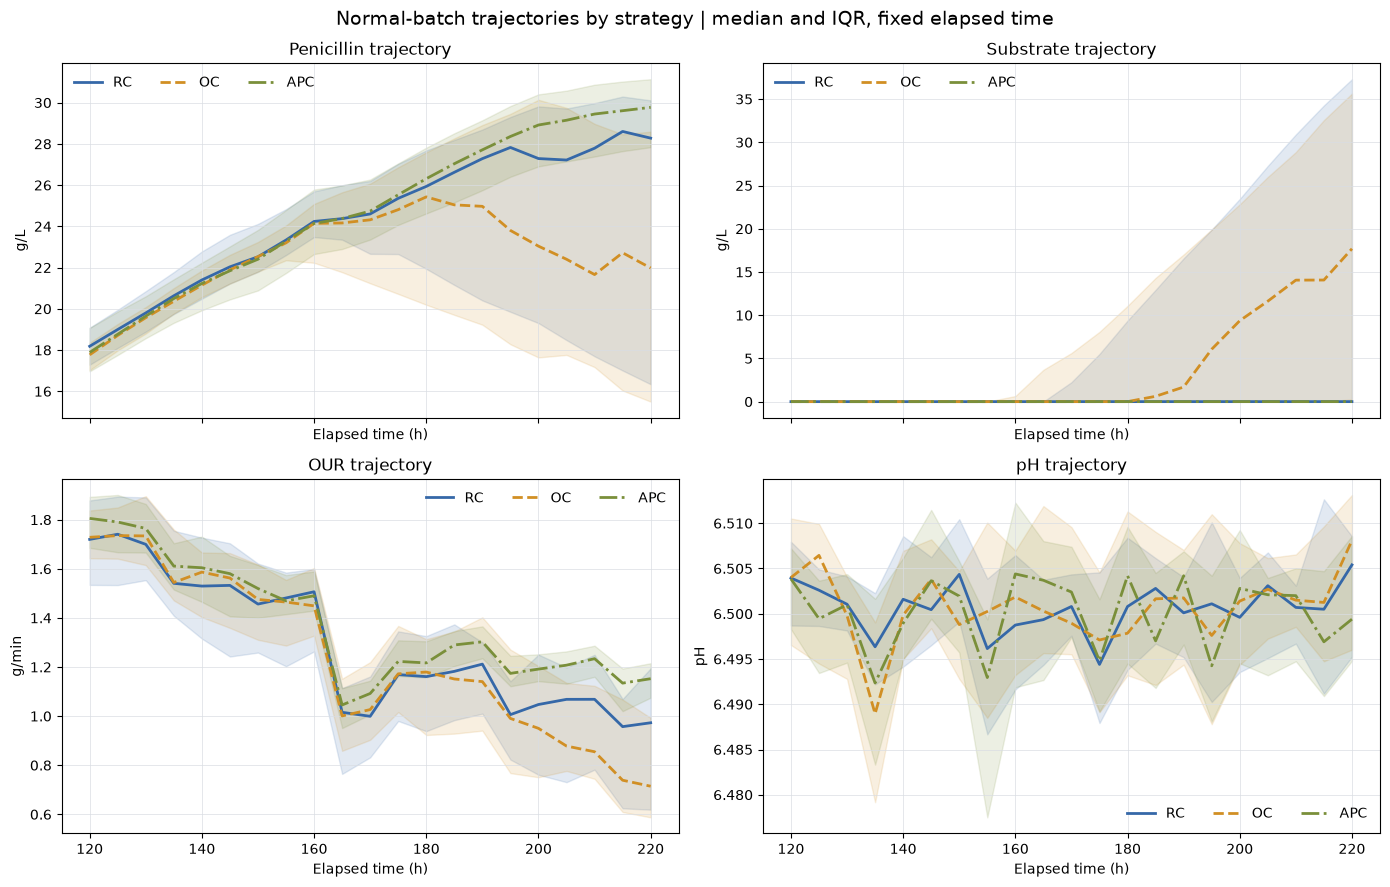

전략,APC,OC,RC
시간,,,
120,30,30,30
150,30,30,30
180,29,30,29
210,26,27,25


In [2]:
variables = {
    'Penicillin': ('페니실린농도(g/L)', 'g/L'),
    'Substrate': ('기질농도(g/L)', 'g/L'),
    'OUR': ('산소소모율(g/min)', 'g/min'),
    'pH': ('pH', 'pH'),
}
time_grid = np.arange(0, 221, 5)
trajectory_rows = []
for batch_number, batch in data.groupby('배치번호', sort=True):
    batch = batch.sort_values('발효시간(h)')
    observed_time = batch['발효시간(h)'].to_numpy()
    strategy = batch['전략'].iloc[0]
    for elapsed_time in time_grid:
        if elapsed_time < observed_time[0] or elapsed_time > observed_time[-1]:
            continue
        row = {'배치번호': batch_number, '전략': strategy, '시간': elapsed_time}
        for label, (column, _) in variables.items():
            row[label] = np.interp(elapsed_time, observed_time, batch[column].to_numpy())
        trajectory_rows.append(row)
trajectories = pd.DataFrame(trajectory_rows)

palette = {'RC': '#3568A8', 'OC': '#D18F24', 'APC': '#7A8F3A'}
line_styles = {'RC': '-', 'OC': '--', 'APC': '-.'}
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for axis, (label, (_, unit)) in zip(axes.flat, variables.items()):
    for strategy in ['RC', 'OC', 'APC']:
        summary = trajectories.loc[(trajectories['전략'] == strategy) & (trajectories['시간'] >= 120)].groupby('시간')[label].agg(
            median='median', q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75), count='count'
        ).reset_index()
        valid = summary['count'] >= 5
        axis.plot(summary.loc[valid, '시간'], summary.loc[valid, 'median'], color=palette[strategy],
                  linestyle=line_styles[strategy], linewidth=2, label=strategy)
        axis.fill_between(summary.loc[valid, '시간'], summary.loc[valid, 'q1'], summary.loc[valid, 'q3'],
                          color=palette[strategy], alpha=0.14)
    axis.set_title(f'{label} trajectory')
    axis.set_ylabel(unit)
    axis.set_xlabel('Elapsed time (h)')
    axis.grid(color='#D9DDE3', linewidth=0.7, alpha=0.7)
    axis.legend(frameon=False, ncol=3)
fig.suptitle('Normal-batch trajectories by strategy | median and IQR, fixed elapsed time', fontsize=14)
fig.tight_layout()
plt.show()

coverage = trajectories.loc[trajectories['시간'].isin([120, 150, 180, 210])].groupby(['시간', '전략'])['배치번호'].nunique().unstack()
display(coverage)

### 판단

120~180시간에는 전략별 궤적 비교가 가능하다. 210시간 이후에는 일부 배치가 이미 종료되어 중앙값이 장기 배치에 편향될 수 있으므로 후기 설명자료로만 사용한다. 동일 시간대의 전략 차이는 보이지만, 이 그림만으로 성공과 저성과를 구분하는 운영 경계를 정할 수는 없다.

In [3]:
yield_table = data.groupby('배치번호')['총수확량(kg)'].first().rename('총수확량').reset_index()
yield_table['전략'] = np.select([yield_table['배치번호'] <= 30, yield_table['배치번호'] <= 60], ['RC', 'OC'], default='APC')
yield_table['전략내순위'] = yield_table.groupby('전략')['총수확량'].rank(ascending=False, method='first')
yield_table['성과그룹'] = np.select(
    [yield_table['전략내순위'] <= 8, yield_table['전략내순위'] >= 23],
    ['성공', '저성과'], default='중간'
)
fixed_times = np.arange(50, 166, 5)
comparison_rows = []
for elapsed_time in fixed_times:
    time_rows = []
    for batch_number, batch in data.groupby('배치번호', sort=True):
        batch = batch.sort_values('발효시간(h)')
        observed_time = batch['발효시간(h)'].to_numpy()
        row = {'배치번호': batch_number}
        for label, (column, _) in variables.items():
            row[label] = np.interp(elapsed_time, observed_time, batch[column].to_numpy())
        time_rows.append(row)
    time_data = pd.DataFrame(time_rows).merge(yield_table[['배치번호', '전략', '성과그룹']], on='배치번호')
    for label in variables:
        time_data['표준화값'] = time_data.groupby('전략')[label].transform(lambda x: (x - x.mean()) / x.std(ddof=1))
        success = time_data.loc[time_data['성과그룹'].eq('성공'), '표준화값']
        low = time_data.loc[time_data['성과그룹'].eq('저성과'), '표준화값']
        test = stats.mannwhitneyu(success, low, alternative='two-sided')
        comparison_rows.append({
            '시간': elapsed_time, '지표': label,
            '성공-저성과_z평균차': success.mean() - low.mean(), 'p값': test.pvalue,
        })
separation_results = pd.DataFrame(comparison_rows)
separation_results['FDR'] = fdr_bh(separation_results['p값'])
separated = separation_results.loc[(separation_results['FDR'] < 0.05) & (separation_results['성공-저성과_z평균차'].abs() >= 0.5)]
print(f'50~165시간 중 FDR 유의하고 |표준화 평균차|≥0.5인 지점: {len(separated)}개')
display(separation_results.sort_values('FDR').head(12).round(6))

50~165시간 중 FDR 유의하고 |표준화 평균차|≥0.5인 지점: 0개


,시간,지표,성공-저성과_z평균차,p값,FDR
0,50,Penicillin,-0.060598,0.556760,0.991774
1,50,Substrate,-0.088152,0.975326,0.991774
2,50,OUR,-0.008873,0.860870,0.991774
3,50,pH,-0.228817,0.877089,0.991774
4,55,Penicillin,-0.111425,0.718216,0.991774
5,55,Substrate,-0.223566,0.516003,0.991774
6,55,OUR,-0.082145,0.828593,0.991774
7,55,pH,-0.078375,0.828584,0.991774
8,60,Penicillin,-0.130401,0.733688,0.991774
9,60,Substrate,-0.152682,0.877099,0.991774


### 판단

50~165시간의 순간값에서는 성공 상위 8개와 저성과 하위 8개가 FDR 기준으로 안정적으로 갈라지는 시점을 찾지 못했다. 따라서 페니실린·기질·OUR·pH의 단일 시점 수준값만으로 165시간 이전 관리경계를 설정하는 것은 근거가 부족하다. 이전 분석에서 확인된 차이는 후기 기울기와 누적 산 투입량처럼 시간축을 요약한 특징에서 더 분명하다.

In [4]:
reference_rows = []
for strategy in ['RC', 'OC', 'APC']:
    selected_batches = data.loc[(data['전략'] == strategy) & data['배치번호'].isin(golden_ids)]
    for elapsed_time in [150, 180]:
        for label, (column, unit) in variables.items():
            values = []
            for _, batch in selected_batches.groupby('배치번호'):
                batch = batch.sort_values('발효시간(h)')
                observed_time = batch['발효시간(h)'].to_numpy()
                if elapsed_time <= observed_time[-1]:
                    values.append(np.interp(elapsed_time, observed_time, batch[column].to_numpy()))
            reference_rows.append({
                '전략': strategy, '시간': elapsed_time, '지표': label, '단위': unit, '배치수': len(values),
                'Q1_참고하한': np.quantile(values, 0.25), '중앙값': np.median(values), 'Q3_참고상한': np.quantile(values, 0.75),
            })
reference_bands = pd.DataFrame(reference_rows)
display(reference_bands.round(4))

,전략,시간,지표,단위,배치수,Q1_참고하한,중앙값,Q3_참고상한
0,RC,150,Penicillin,g/L,6,22.1915,22.7510,23.6322
1,RC,150,Substrate,g/L,6,0.0004,0.0005,0.0005
2,RC,150,OUR,g/min,6,1.3002,1.4297,1.5911
3,RC,150,pH,pH,6,6.4995,6.4998,6.5030
4,RC,180,Penicillin,g/L,6,25.9320,26.6390,27.6812
5,RC,180,Substrate,g/L,6,0.0013,0.0013,0.0015
6,RC,180,OUR,g/min,6,1.2182,1.2950,1.3618
7,RC,180,pH,pH,6,6.4988,6.5017,6.5081
8,OC,150,Penicillin,g/L,3,23.4065,24.4900,24.9910
9,OC,150,Substrate,g/L,3,0.0006,0.0007,0.0008


### 최종 판단과 결론

- 전략별 후기 궤적은 고정시간 기준으로 비교할 수 있지만 210시간 이후에는 종료 배치 탈락에 따른 생존 편향을 주의해야 한다.
- 165시간 이전에는 네 변수의 순간값만으로 성공과 저성과가 통계적으로 갈라지는 시점이 없었다. 조기 운영판정에는 수준값보다 이동창 기울기, 변화량, 누적 산 투입량을 사용해야 한다.
- 150·180시간 골든배치 Q1~Q3는 재현 가능한 경험적 참고밴드다. OC는 배치가 3개뿐이므로 밴드가 특히 불안정하다.
- 이 밴드를 현장 관리한계로 바로 사용하면 안 된다. 장비 허용범위·공정지식·추가 배치 검증을 결합한 뒤 경보한계와 조치한계를 별도로 확정해야 한다.